# 03 · Tokens are not characters

*Compiling a schema for a tokenizer: why `pcd` tokenizes every JSON line in context, where the newline goes, and how each field's decision position and label trie fall out of the tokens.*

> **TL;DR**
> - Tokenize the key and the value separately and you ask the model about a split it never saw. After a key like `"sla_breach_risk": ` with its dangling space, Qwen2.5-1.5B gives `true` and `false` together a median of 1.6e-5 of its probability and often wants to write a digit instead. Tokenized as one line, the same question puts most of the probability on ` true` and ` false`.
> - `pcd` tokenizes every complete JSON line right after the prompt's tail, and refuses to compile if the tokenizer merges across that seam.
> - The newline is part of the line. Qwen writes `",\n` as one token; scoring the bare `",` instead costs about 7 nats per label, uneven enough between labels to flip about one full-string decision in ten. Where the newline attaches depends on the tokenizer, so the compiler tries two layouts.
> - Everything else falls out of the tokens: the decision position is the longest common token prefix, and the labels form a token trie. Same schema, different tokenizer, different trie: Qwen spells the `000` of `CAT_000` digit by digit, Llama 3 as one token.

Post [02](02_schemas_and_prompts.ipynb) built the prompt. This post is about the step between the prompt and the model: `compiler.py`, which turns every field into token sequences. We use Qwen2.5-1.5B-Instruct (4-bit MLX) for the measurements and ten tokenizers for the comparisons.

In [1]:
from nbutils import *
import time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from pcd import Engine, PromptFormat, Schema
from pcd.backends.base import Query
from pcd.compiler import TokenizationError, compile_schema, encode_after
from pcd.tokenizer import HFTokenizer

environment()
engine = Engine(load())          # qwen2.5-1.5b, 4-bit MLX
backend, tok = engine.backend, engine.tokenizer
V = tuple(range(tok.vocab_size))
preset = load_preset("support_triage")
ticket, triage = preset["context"], preset["schema"]
cs = engine.compile(triage)

Apple M1 Pro, 16 GB | macOS 15.1.1 | Python 3.13.5 | pcd 0.1.0, mlx 0.32.2, mlx-lm 0.31.3, torch 2.14.0, transformers 5.17.0


## 1. The naive way: tokenize the pieces

The obvious way to score a boolean is to tokenize the text up to the value, `  "sla_breach_risk": `, append it to the prompt, and compare the next-token probabilities of `true` and `false`. The original engine did exactly that. Here are the pieces, and the same line tokenized as a whole:

In [2]:
show_tokens(tok, '  "sla_breach_risk": ', "key part")
show_tokens(tok, "true", "value")
show_tokens(tok, '  "sla_breach_risk": true,\n', "whole line");

key part      │·│·"│sla│_b│reach│_r│isk│":│·│   (9 tokens)
value         │true│   (1 tokens)
whole line    │·│·"│sla│_b│reach│_r│isk│":│·true│,⏎│   (10 tokens)


In the whole line, the space after the colon belongs to the value: ` true` is a single token. Split in two, the key part ends in a lone space token and the value is the space-less `true`. That pair of tokens essentially never occurs in JSON, so we are asking the model about text it would not write.

How much does that matter? We score both versions of every boolean in the triage schema. To measure exactly what the engine sees, we rebuild its prefix: the prompt, plus the answer line of the schema's first field, which the engine writes before deciding the others (post [06](06_engine_and_benchmarks.ipynb) explains why).

In [3]:
def engine_prefix(name):
    """(preset, compiled schema, extraction, KV prefix, anchor text) as the engine has them when
    it decides fields 2..n: the prompt plus the first field's answer line."""
    p = load_preset(name)
    c = engine.compile(p["schema"])
    out = engine.extract(p["context"], p["schema"])
    prompt_prefix = backend.prefill(tok.encode(c.prompt.render(p["context"].strip())))
    first = c.schema.names[0]
    line = c.answer_text({first: out.values[first]})
    prefix = backend.prefill(encode_after(tok, c.prompt.tail, line), parent=prompt_prefix)
    return p, c, out, prompt_prefix, prefix, c.prompt.tail + line


def next_token_logprobs(prefix, rows):
    """Full-vocabulary log-probabilities after the last token of each row, in one batched pass."""
    return backend.score(prefix, rows, [Query(i, len(r) - 1, V) for i, r in enumerate(rows)])


_, c, out, _, prefix, anchor = engine_prefix("support_triage")
bools = [n for n in c.schema.names[1:] if c.schema[n].type == "boolean"]
T, F, ST, SF, SQ = (tok.encode(s)[0] for s in ["true", "false", " true", " false", ' "'])

rows = []
for n in bools:
    rows += [encode_after(tok, anchor, f'  "{n}": '), c.fields[n].prefix]     # naive row, pcd's row
lps = next_token_logprobs(prefix, rows)

table, naive_mass, ctx_mass, quote_mass, flips = [], [], [], [], []
for k, n in enumerate(bools):
    a, b = np.exp(lps[2 * k]), np.exp(lps[2 * k + 1])
    top = int(np.argmax(a))
    naive_mass.append(a[T] + a[F]); ctx_mass.append(b[ST] + b[SF]); quote_mass.append(b[SQ])
    naive_says, ctx_says = a[T] > a[F], b[ST] > b[SF]
    if naive_says != ctx_says:
        flips.append(n)
    table.append([n, f"{a[T]:.1e}", f"{a[F]:.1e}", f"`{vis(tok.decode([top]))}` {a[top]:.2f}",
                  f"{b[ST]:.2f}", f"{b[SF]:.2f}", "" if naive_says == ctx_says else "flips"])
md_table(["field", "naive `true`", "naive `false`", "model's top token after `\": `",
          "in context ` true`", "in context ` false`", ""], table)

| field | naive `true` | naive `false` | model's top token after `": ` | in context ` true` | in context ` false` |  |
|---|---|---|---|---|---|---|
| sla_breach_risk | 3.1e-05 | 8.7e-06 | `1` 0.51 | 0.63 | 0.29 |  |
| requires_executive_escalation | 8.7e-06 | 3.8e-06 | `·true` 0.39 | 0.77 | 0.10 |  |
| can_resolve_autonomously | 1.0e-06 | 1.7e-05 | `0` 0.53 | 0.03 | 0.54 |  |
| confidence_above_auto_threshold | 2.5e-05 | 6.1e-05 | `0` 0.53 | 0.12 | 0.59 |  |
| refund_recommended | 2.1e-05 | 9.3e-06 | `·true` 0.36 | 0.79 | 0.09 |  |
| requires_legal_review | 8.2e-06 | 5.9e-06 | `1` 0.35 | 0.75 | 0.21 |  |
| security_incident | 9.4e-06 | 1.5e-06 | `1` 0.59 | 0.83 | 0.04 |  |
| compliance_breach | 1.3e-05 | 1.4e-06 | `·true` 0.58 | 0.95 | 0.02 |  |
| requires_phone_call | 1.5e-05 | 3.1e-06 | `·true` 0.59 | 0.92 | 0.07 |  |
| notify_account_executive | 3.2e-06 | 5.2e-06 | `·false` 0.46 | 0.51 | 0.41 | flips |
| public_status_page_incident | 5.5e-06 | 9.0e-06 | `·false` 0.53 | 0.48 | 0.47 | flips |
| postmortem_required | 2.1e-05 | 6.9e-06 | `·true` 0.43 | 0.64 | 0.22 |  |
| vendor_fault | 2.7e-06 | 1.3e-05 | `·false` 0.58 | 0.25 | 0.60 |  |
| contract_penalty_applicable | 7.3e-06 | 1.0e-05 | `·false` 0.33 | 0.47 | 0.41 | flips |
| escalate_to_vp | 5.2e-06 | 3.7e-06 | `·true` 0.39 | 0.65 | 0.26 |  |

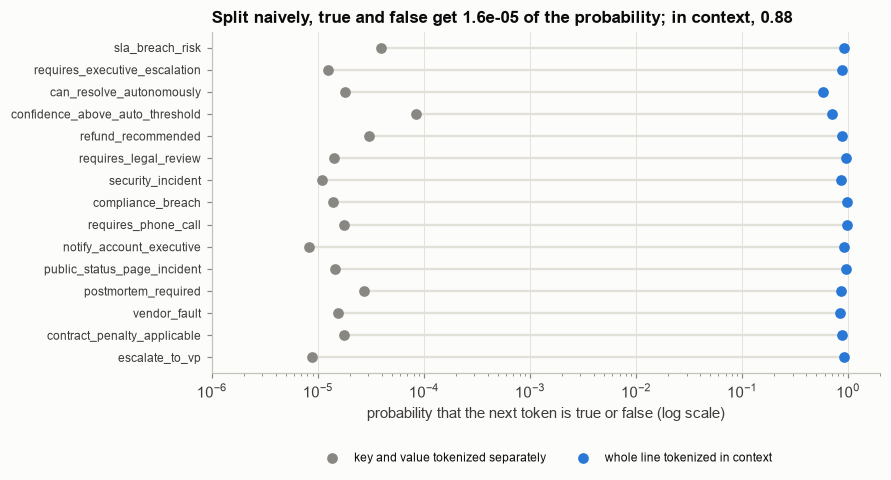

naive     P(true) + P(false): median 1.6e-05  (range 8.4e-06 to 8.5e-05)
in context P( true) + P( false): median 0.88, and P( ") median 0.11
decisions that differ between the two: 3 of 15 ['notify_account_executive', 'public_status_page_incident', 'contract_penalty_applicable']


In [4]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
y = np.arange(len(bools))
ax.scatter(naive_mass, y, color=MUTED, label="key and value tokenized separately", zorder=3)
ax.scatter(ctx_mass, y, color=SERIES[0], label="whole line tokenized in context", zorder=3)
ax.hlines(y, naive_mass, ctx_mass, color=GRID, linewidth=1.5, zorder=2)
ax.set_xscale("log"); ax.set_xlim(1e-6, 2)
ax.set_yticks(y, bools, fontsize=8); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("probability that the next token is true or false (log scale)")
ax.set_title(f"Split naively, true and false get {np.median(naive_mass):.1e} of the probability; in context, {np.median(ctx_mass):.2f}")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=2, fontsize=8)
plt.tight_layout(); plt.show()
print(f"naive     P(true) + P(false): median {np.median(naive_mass):.1e}  (range {min(naive_mass):.1e} to {max(naive_mass):.1e})")
print(f"in context P( true) + P( false): median {np.median(ctx_mass):.2f}, and P( \") median {np.median(quote_mass):.2f}")
print(f"decisions that differ between the two: {len(flips)} of {len(bools)} {flips}")

After the dangling space, the model's favorite continuation is a digit for several fields: a value that starts after a separate space token looks like a number to it. For the others it is ` true` or ` false` *with* a leading space, as if it wanted to write a second space. The space-less `true` and `false` we are asking about get a median of 1.6e-5 between them. Tokenized in context, the same question puts most of the probability on ` true` and ` false`, and most of the rest on ` "`, the start of a quoted boolean, which post [04](04_decoding.ipynb) deals with.

The naive decisions are not random: renormalizing two slivers still picks the same side as the in-context comparison for most fields, because the slivers still carry some of the model's opinion. The fields that flip are the close calls. The real damage is that the numbers stop meaning anything. A probability computed from about 1e-5 of the mass cannot tell a confident answer from noise, and the candidate mass of post [02](02_schemas_and_prompts.ipynb) would flag every one of these fields.

## 2. Tokenize in context, and check the seam

The fix is to never tokenize a piece of a line on its own. For every field, label and surface form, the compiler writes out the complete JSON line the model would produce, appends it to the prompt's tail, tokenizes the whole string, and strips the tail's tokens off the front:

In [5]:
show_source(encode_after)

# src/pcd/compiler.py
125  def encode_after(tokenizer: Tokenizer, anchor: str, text: str, what: str = "text") -> tuple[int, ...]:
126      """Tokens of ``text`` as they appear right after ``anchor``.
127  
128      Raises TokenizationError if the anchor's own tokens change when ``text`` follows,
129      i.e. if the tokenizer merges across the boundary.
130      """
131      a = tokenizer.encode(anchor)
132      full = tokenizer.encode(anchor + text)
133      if full[: len(a)] != a:
134          raise TokenizationError(
135              f"tokenization of {what} merges with the text before it "
136              f"(anchor ends {anchor[-12:]!r}, text starts {text[:24]!r}). "
137              "Try a different PromptFormat.indent, or see CONTRIBUTING.md."
138          )
139      return tuple(full[len(a):])


The check matters as much as the slicing. BPE tokenizers merge across any boundary they like, and if the tail's last token changes when a line follows it, the tokens we strip are not the tokens the prompt was prefilled with. The compiler would then build rows that do not continue the prompt at all. Qwen's tokenizer, for example, has a single token for `{` followed by a newline:

In [6]:
show_tokens(tok, "{", "brace")
show_tokens(tok, '{\n  "a": true,', "brace + line")
try:
    encode_after(tok, "{", '\n  "a": true,')
except TokenizationError as e:
    print(f"\nTokenizationError: {e}")

brace         │{│   (1 tokens)
brace + line  │{⏎│·│·"│a│":│·true│,│   (7 tokens)

TokenizationError: tokenization of text merges with the text before it (anchor ends '{', text starts '\n  "a": true,'). Try a different PromptFormat.indent, or see CONTRIBUTING.md.


So a prompt that ends in `{` and lines that start with a newline cannot work with this tokenizer. Section 4 shows how the compiler uses exactly this error to choose where newlines go.

In-context tokenization needs no special cases. The lesson of section 1 is not "never end a row on a space": it is "end the row where the tokenizer would". Qwen splits digits one per token and writes the space before a number as its own token, so for an integer field the correct row *does* end in a lone space:

In [7]:
ints = compile_schema(Schema.coerce({"retry_after_hours": {"type": "enum", "choices": [1, 12, 24]}}), tok, PromptFormat())
show_tokens(tok, ints.fields["retry_after_hours"].prefix[-4:], "row ends")
show_tokens(tok, encode_after(tok, ints.prompt.tail, '  "retry_after_hours": 12,\n'), "whole line");

row ends      │_after│_hours│":│·│   (4 tokens)
whole line    │·│·"│retry│_after│_hours│":│·│1│2│,⏎│   (10 tokens)


And strings split differently alone than in a line. Tokenized on its own, `"P0_EMERGENCY"` starts with a `"P` token; in the line, the quote goes with the space before it:

In [8]:
rows = []
for name, label in [("ticket_priority", "P0_EMERGENCY"), ("sentiment", "NEGATIVE"), ("severity_tier", "SEV_0_CRITICAL")]:
    alone = tok.encode(f'"{label}"')
    in_line = encode_after(tok, cs.prompt.tail + f'  "{name}":', f' "{label}",\n')
    rows.append([name, "`" + "│".join(vis(p) for p in pieces(tok, alone)) + "`",
                 "`" + "│".join(vis(p) for p in pieces(tok, in_line)) + "`"])
md_table(["field", "value tokenized alone", "the same value in its line, after `\":`"], rows)

| field | value tokenized alone | the same value in its line, after `":` |
|---|---|---|
| ticket_priority | `"P│0│_EM│ER│GENCY│"` | `·"│P│0│_EM│ER│GENCY│",⏎` |
| sentiment | `"│NEG│ATIVE│"` | `·"│NEG│ATIVE│",⏎` |
| severity_tier | `"│SE│V│_│0│_CRITICAL│"` | `·"│SE│V│_│0│_CRITICAL│",⏎` |

## 3. The newline belongs to the line

The line includes its newline, and that is not a formatting detail. Qwen writes a closing quote, comma and newline as one token, `",⏎`. Leave the newline out and the line ends in the bare token `",`:

In [9]:
show_tokens(tok, encode_after(tok, cs.prompt.tail, '  "sentiment": "NEGATIVE",\n'), "with newline")
show_tokens(tok, encode_after(tok, cs.prompt.tail, '  "sentiment": "NEGATIVE",'), "without");

with newline  │·│·"│sent│iment│":│·"│NEG│ATIVE│",⏎│   (9 tokens)
without       │·│·"│sent│iment│":│·"│NEG│ATIVE│",│   (9 tokens)


The default decoder stops at the token that identifies a label, so it never reaches the closing token. But exact scoring does: it sums the log-probabilities of every token of every label, to let the tokens after the first one weigh in (post [04](04_decoding.ipynb)). Whatever the line ends with is part of every score. We score each label's full line twice, ending in `",⏎` and in the bare `",`, on the prefixes the engine uses:

In [10]:
def full_line_scores(name):
    """Per field and label: log-probs of every token of the value line, ending with and without its newline."""
    p, c, out, prompt_prefix, prefix, anchor = engine_prefix(name)
    first = c.schema.names[0]
    scores = {}
    for group, pre, anc in [([first], prompt_prefix, c.prompt.tail), (c.schema.names[1:], prefix, anchor)]:
        rows, meta = [], []
        for n in group:
            f = c.schema[n]
            for lab in f.labels:
                line = c.fmt.field_line(f, lab)
                meta.append((n, lab))
                rows += [encode_after(tok, anc, line), encode_after(tok, anc, line[:-1])]
        queries = [Query(i, pos, (r[pos + 1],))
                   for i, r in enumerate(rows)
                   for pos in range(len(c.fields[meta[i // 2][0]].prefix) - 1, len(r) - 1)]
        per_row = {}
        for q, lp in zip(queries, backend.score(pre, rows, queries)):
            per_row.setdefault(q.row, []).append(float(lp[0]))
        for i, (n, lab) in enumerate(meta):
            scores.setdefault(n, {})[lab] = (per_row[2 * i], per_row[2 * i + 1])
    return scores


triage_scores = full_line_scores("support_triage")
md_table(["`sentiment` label", "closing `\",⏎`", "closing `\",`", "full line, with newline", "full line, without"],
         [[f"`{lab}`", f"{nl[-1]:.3f}", f"{bare[-1]:.2f}", f"{sum(nl):.2f}", f"{sum(bare):.2f}"]
          for lab, (nl, bare) in triage_scores["sentiment"].items()])

| `sentiment` label | closing `",⏎` | closing `",` | full line, with newline | full line, without |
|---|---|---|---|---|
| `VERY_NEGATIVE` | -0.000 | -8.23 | -0.94 | -9.18 |
| `NEGATIVE` | -0.000 | -8.11 | -0.94 | -9.05 |
| `NEUTRAL` | -0.001 | -6.97 | -3.98 | -10.95 |
| `POSITIVE` | -0.001 | -7.42 | -1.63 | -9.05 |

All numbers are log-probabilities in nats. With the newline, the closing token costs nothing: once the model has written `NEGATIVE`, it is certain the line ends. The bare `",` costs several nats, and not the same number for every label. That unevenness is the problem: a constant offset would cancel when we compare labels, a varying one adds noise to the comparison. Across three presets:

In [12]:
rows, all_bare = [], []
for name in ["support_triage", "fintech_fraud", "code_security"]:
    sc = triage_scores if name == "support_triage" else full_line_scores(name)
    close_nl = [nl[-1] for f in sc.values() for nl, _ in f.values()]
    close_bare = [bare[-1] for f in sc.values() for _, bare in f.values()]
    all_bare += close_bare
    spread = [max(b[-1] for _, b in f.values()) - min(b[-1] for _, b in f.values()) for f in sc.values()]
    flipped = [n for n, f in sc.items()
               if max(f, key=lambda l: sum(f[l][0])) != max(f, key=lambda l: sum(f[l][1]))]
    rows.append([name, f"{np.median(close_nl):.3f}", f"{np.median(close_bare):.2f}",
                 f"{min(close_bare):.1f} to {max(close_bare):.1f}", f"{np.median(spread):.2f} / {max(spread):.2f}",
                 f"{len(flipped)} of {len(sc)}"])
md_table(["preset", "closing `\",⏎` (median)", "closing `\",` (median)", "`\",` range", "spread within a field (median / max)",
          "full-line winner changes"], rows)
print(f"bare closing token over all {len(all_bare)} labels: median {np.median(all_bare):.2f} nats")

| preset | closing `",⏎` (median) | closing `",` (median) | `",` range | spread within a field (median / max) | full-line winner changes |
|---|---|---|---|---|---|
| support_triage | -0.001 | -7.64 | -9.7 to -5.1 | 0.69 / 2.70 | 3 of 28 |
| fintech_fraud | -0.002 | -6.79 | -9.5 to -4.0 | 0.67 / 2.94 | 2 of 28 |
| code_security | -0.001 | -7.08 | -9.6 to -4.4 | 0.69 / 2.24 | 4 of 28 |

bare closing token over all 241 labels: median -7.24 nats


The bare ending costs about 7 nats per label, in line with the 7 to 8 nats noted in the project README. Within a field it varies by most of a nat typically and by a few nats at worst, enough to change the winner of a full-line comparison in the fields counted in the last column. None of this is visible in the output: the answer is still a valid label. That is why the compiler builds every line with its newline.

## 4. Where the newline goes depends on the tokenizer

"Include the newline" raises the question of which side of the newline to put the token boundary on. It depends on the tokenizer family. Here are two JSON lines through four tokenizers:

In [13]:
TOKENIZERS = {
    "Qwen2.5": "mlx-community/Qwen2.5-1.5B-Instruct-4bit",
    "Qwen3": "Qwen/Qwen3-0.6B",
    "Qwen3.5": "Qwen/Qwen3.5-0.8B",
    "Llama 3.2": "mlx-community/Llama-3.2-1B-Instruct-4bit",
    "Gemma 2": "mlx-community/gemma-2-2b-it-4bit",
    "Gemma 3": "mlx-community/gemma-3-1b-it-4bit",
    "Gemma 4": "google/gemma-4-e2b-it",
    "SmolLM2": "HuggingFaceTB/SmolLM2-360M-Instruct",
    "SmolLM3": "HuggingFaceTB/SmolLM3-3B",
    "LFM2.5": "LiquidAI/LFM2.5-1.2B-Instruct",
}
toks = {k: HFTokenizer(AutoTokenizer.from_pretrained(r)) for k, r in TOKENIZERS.items()}
for k in ["Qwen2.5", "Llama 3.2", "Gemma 3", "SmolLM2"]:
    show_tokens(toks[k], '{\n  "a": true,\n  "b": "X",\n}', k)

Qwen2.5       │{⏎│·│·"│a│":│·true│,⏎│·│·"│b│":│·"│X│",⏎│}│   (15 tokens)
Llama 3.2     │{⏎│·│·"│a│":│·true│,⏎│·│·"│b│":│·"│X│",⏎│}│   (15 tokens)
Gemma 3       │{│⏎│··│"│a│":│·true│,│⏎│··│"│b│":│·"│X│",│⏎│}│   (18 tokens)
SmolLM2       │{│⏎·│·"│a│":│·true│,│⏎·│·"│b│":│·"│X│",│⏎│}│   (16 tokens)


Three behaviors:

- **Qwen and Llama 3** (GPT-4-style BPE) glue the newline to the punctuation before it: `{⏎`, `,⏎`, `",⏎`.
- **Gemma** (SentencePiece) makes the newline its own token.
- **SmolLM2** (GPT-2-style BPE) glues the newline to the indentation *after* it: `⏎·`.

So there are two layouts. In **"after"**, the prompt's tail ends with `{\n` and each line is `  "key": value,\n`. In **"before"**, the tail ends with `{` and each line is `\n  "key": value,`. Only a layout whose seams tokenize cleanly can work, and `compile_schema` tries "after" first and falls back to "before" (`PromptFormat.newline="auto"`). We can force each layout and watch it fail:

In [14]:
demo = Schema.coerce({
    "deadline": {"type": "enum", "choices": ["1_HOUR", "12_HOURS", "1_WEEK", "NONE"]},
    "wants_refund": {"type": "boolean"},
})
rows = []
for k in ["Qwen2.5", "Llama 3.2", "Gemma 3", "SmolLM2"]:
    ok = {}
    for layout in ["after", "before"]:
        try:
            compile_schema(demo, toks[k], PromptFormat(newline=layout))
            ok[layout] = "clean"
        except TokenizationError as e:
            ok[layout] = "merges"
            if k == "SmolLM2":
                smol_error = e
    auto = compile_schema(demo, toks[k], PromptFormat())
    rows.append([k, ok["after"], ok["before"], f"**{auto.prompt.layout}**", f"`{vis(auto.prompt.tail[-10:])}`"])
md_table(["tokenizer", "\"after\"", "\"before\"", "picked", "tail ends with"], rows)
print(str(smol_error).replace("\n", "\n    "))

| tokenizer | "after" | "before" | picked | tail ends with |
|---|---|---|---|---|
| Qwen2.5 | clean | merges | **after** | `sistant⏎{⏎` |
| Llama 3.2 | clean | merges | **after** | `r_id\|>⏎⏎{⏎` |
| Gemma 3 | clean | clean | **after** | `n>model⏎{⏎` |
| SmolLM2 | merges | clean | **before** | `ssistant⏎{` |

no JSON layout tokenizes cleanly for this tokenizer:
      'after' layout: tokenization of field 'deadline' merges with the text before it (anchor ends 'assistant\n{\n', text starts '  "deadline": "1_HOUR",\n'). Try a different PromptFormat.indent, or see CONTRIBUTING.md.


With SmolLM2 in the "after" layout, the tail's final newline merges with the indentation of the first line into a single `⏎·` token, which is exactly the seam `encode_after` checks. The "before" layout moves the newline to the start of each line, where SmolLM2 wants it, so its tail stops at the brace. That is the difference post [02](02_schemas_and_prompts.ipynb) noticed in SmolLM2's rendered prompt. Qwen and Llama fail the other way round, on the `{⏎` token from section 2. Gemma's standalone newline tokenizes cleanly either way.

The layout also changes which token closes a line. In "after", it is `",⏎` (Qwen) or `",` followed by `⏎` (Gemma); in "before", SmolLM2's line ends at `",` and the newline goes to the start of the next line, which is where SmolLM2 would write it. Either way, the line ends where the model's own text would.

## 5. The decision position

Once every line is a token sequence, the rest is bookkeeping on tokens. A field's row, `CompiledField.prefix`, is the longest common *token* prefix of all its lines, and its last token is the decision position: the distribution there is where the labels first part ways. Some fields of the triage schema:

In [15]:
rows = []
for name in ["sentiment", "severity_tier", "ticket_priority", "sla_breach_risk", "churn_risk_level", "target_resolution_hours"]:
    cf = cs.fields[name]
    firsts = sorted({tok.decode([v.seq[0]]) for v in cf.canonical_variants()})
    rows.append([name, "`" + "│".join(vis(p) for p in pieces(tok, cf.prefix[-4:])) + "`",
                 ", ".join(f"`{vis(t)}`" for t in firsts), len(cf.prefix)])
md_table(["field", "row ends with", "tokens compared at the decision position", "row length"], rows)

| field | row ends with | tokens compared at the decision position | row length |
|---|---|---|---|
| sentiment | `sent│iment│":│·"` | `NE`, `NEG`, `POS`, `VERY` | 6 |
| severity_tier | `·"│SE│V│_` | `0`, `1`, `2`, `3` | 10 |
| ticket_priority | `_priority│":│·"│P` | `0`, `1`, `2`, `3` | 7 |
| sla_breach_risk | `reach│_r│isk│":` | `·false`, `·true` | 8 |
| churn_risk_level | `isk│_level│":│·"` | `CR`, `HIGH`, `LOW`, `M` | 9 |
| target_resolution_hours | `_resolution│_hours│":│·"` | `1`, `2`, `4` | 7 |

The table shows three things that a character-level view gets wrong.

- `NEUTRAL` and `NEGATIVE` share the characters `NE`, but not a token: Qwen writes `NE` for one and `NEG` for the other. They are told apart at the very first token.
- Every `severity_tier` label starts with the tokens `SE`, `V`, `_`, so those go into the row and the decision is the digit. The same happens with `P` for `ticket_priority`. Tokens the schema fixes cost the model nothing to "write".
- For a boolean, the row stops at `":`, because the space belongs to the value token.

`target_resolution_hours` compares only three first tokens for four labels: `1_HOUR` and `12_HOURS` both start with `1`. One token cannot decide that field.

## 6. Variants, surface forms and the label trie

After the row, each label has one or more **variants**, one per way of writing it: the canonical form, plus `"true"`/`"false"` in quotes for booleans (`PromptFormat.quoted_booleans`). A variant is the rest of the line as tokens, plus its **identification depth**: the first token that only this label can produce. Together the variants form a token trie. Here it is for a `deadline` field with a collision, and for a boolean. The token in brackets identifies the label:

In [16]:
def show_trie(tk, cf):
    """Print a compiled field's variants as a token trie. Single-child chains are drawn on one line;
    [brackets] mark the token that identifies the label."""
    print("…" + "".join(vis(p) for p in pieces(tk, cf.prefix[-5:])) + "   ← decision position")

    def walk(path, variants, indent):
        groups = {}
        for v in variants:
            groups.setdefault(v.seq[len(path)], []).append(v)
        for gi, (t, vs) in enumerate(groups.items()):
            last = gi == len(groups) - 1
            chain, p = [t], path + (t,)
            while all(len(v.seq) > len(p) for v in vs) and len({v.seq[len(p)] for v in vs}) == 1:
                chain.append(vs[0].seq[len(p)]); p += (vs[0].seq[len(p)],)
            text = " ─ ".join(f"[{vis(tk.decode([x]))}]" if len(vs) == 1 and vs[0].ident == len(path) + i
                              else vis(tk.decode([x])) for i, x in enumerate(chain))
            done = [v for v in vs if len(v.seq) == len(p)]
            label = f"   → {cf.labels[done[0].label]}" if done else ""
            print(indent + ("└─ " if last else "├─ ") + text + label)
            rest = [v for v in vs if len(v.seq) > len(p)]
            if rest:
                walk(p, rest, indent + ("   " if last else "│  "))

    walk((), list(cf.variants), "")


demo_cs = compile_schema(demo, tok, PromptFormat())
for name in demo.names:
    cf = demo_cs.fields[name]
    print(f"{name}: {len(cf.variants)} variants, has_collision={cf.has_collision}, "
          f"identified at token {[v.ident + 1 for v in cf.variants]}")
    show_trie(tok, cf)
    print()

deadline: 4 variants, has_collision=True, identified at token [2, 2, 2, 1]
…··"deadline":·"   ← decision position
├─ 1
│  ├─ [_HOUR] ─ ",⏎   → 1_HOUR
│  ├─ [2] ─ _H ─ OURS ─ ",⏎   → 12_HOURS
│  └─ [_WEEK] ─ ",⏎   → 1_WEEK
└─ [NONE] ─ ",⏎   → NONE

wants_refund: 4 variants, has_collision=False, identified at token [1, 2, 1, 2]
…wants_refund":   ← decision position
├─ [·true] ─ ,⏎   → True
├─ ·"
│  ├─ [true] ─ ",⏎   → True
│  └─ [false] ─ ",⏎   → False
└─ [·false] ─ ,⏎   → False



`deadline` needs two tokens: `1` opens three branches, and the second token (`_HOUR`, `2` or `_WEEK`) settles it. Post [04](04_decoding.ipynb) shows how the decoder follows each branch just that deep, still in one batched pass.

The boolean has four variants. The bare forms are identified at their first token, ` true` or ` false`. The quoted forms share ` "` and are identified one token later. `has_collision` only looks at the canonical forms, so the boolean does not count as colliding: its trie branches only because of the quoted spellings.

Including the closing punctuation has one more job: it keeps the trie *prefix-free*. Without it, the tokens of `1` would be a prefix of the tokens of `12`, and no decoder could tell "the model wrote `1`" from "the model is about to write `12`". With the line's ending, the comma is what identifies `1`:

In [17]:
show_trie(tok, ints.fields["retry_after_hours"])

…retry_after_hours":·   ← decision position
├─ 1
│  ├─ [,⏎]   → 1
│  └─ [2] ─ ,⏎   → 12
└─ [2] ─ 4 ─ ,⏎   → 24


(The compiler refuses a field where one variant's tokens are a prefix of another's; with the closing punctuation in every line, that can only happen if two labels render to the same text.)

The largest trie in our presets is `customs_category` in `high_cardinality_255`: 255 labels of the form `CAT_000_Live_Animals`.

In [18]:
big = engine.compile(load_preset("high_cardinality_255")["schema"]).fields["customs_category"]
print(f"row ends with: {'│'.join(vis(p) for p in pieces(tok, big.prefix[-3:]))}")
print(f"labels {len(big.labels)}, distinct tokens at the decision position {len({v.seq[0] for v in big.variants})}, "
      f"identified at token {dict(Counter(v.ident + 1 for v in big.variants))}")
for v in big.variants[:3]:
    print("   " + "│".join(vis(p) for p in pieces(tok, v.seq)))

row ends with: ·"│CAT│_
labels 255, distinct tokens at the decision position 3, identified at token {3: 255}
   0│0│0│_L│ive│_An│imals│",⏎
   0│0│1│_M│eat│_│&_│Ed│ible│_Off│al│",⏎
   0│0│2│_F│ish│_│&_│Sea│food│",⏎


Qwen spells numbers one digit per token, so the 255 labels share the row up to `CAT_` and then walk three levels of digits before any label is identified: 3 choices, then 10, then 10. A first-token decoder would see only `0`, `1` and `2`. This is the field where post [04](04_decoding.ipynb) needs its trie walk and hybrid scoring, and section 8 shows that a different tokenizer builds a completely different trie for it.

## 7. Compile once

All of this is pure tokenizer work, no model involved, and it depends only on the schema, the tokenizer and the prompt format. So it runs once:

In [19]:
rows = []
for name in PRESET_NAMES:
    s = Schema.coerce(load_preset(name)["schema"])
    ms, c = timed(lambda: compile_schema(s, tok, PromptFormat()), repeats=3)
    rows.append([name, len(s.names), sum(len(f.variants) for f in c.fields.values()), len(c.head_ids), f"{ms:.0f}"])
md_table(["preset", "fields", "variants", "head tokens", "compile ms"], rows)

| preset | fields | variants | head tokens | compile ms |
|---|---|---|---|---|
| support_triage | 28 | 114 | 901 | 9 |
| fintech_fraud | 28 | 110 | 831 | 8 |
| code_security | 28 | 109 | 927 | 7 |
| high_cardinality_255 | 4 | 266 | 4461 | 27 |

In [20]:
show_source(Engine.compile)

# src/pcd/engine.py
76      def compile(self, schema: Any) -> CompiledSchema:
77          schema = Schema.coerce(schema)
78          key = (schema.fingerprint, self.prompt_format.key())
79          with self._lock:
80              cs = self._compiled.get(key)
81              if cs is None:
82                  cs = compile_schema(schema, self.tokenizer, self.prompt_format)
83                  self._compiled[key] = cs
84                  while len(self._compiled) > 32:
85                      self._compiled.popitem(last=False)
86              else:
87                  self._compiled.move_to_end(key)
88              return cs


The cache key is the schema's fingerprint plus `PromptFormat.key()`, so a dict, a JSON Schema and a Pydantic model for the same fields share one entry (post [02](02_schemas_and_prompts.ipynb) showed they have the same fingerprint), and changing any prompt knob compiles anew:

In [21]:
cold_ms, _ = timed(lambda: compile_schema(Schema.coerce(triage), tok, engine.prompt_format), repeats=3)
warm_ms, _ = timed(lambda: engine.compile(triage), repeats=20)
print(f"engine.compile(triage) is engine.compile(triage): {engine.compile(triage) is engine.compile(triage)}")
print(f"compile {cold_ms:.1f} ms, cached lookup {warm_ms * 1e3:.0f} µs (includes normalizing the dict and fingerprinting it)")
other = Engine(backend, prompt_format=PromptFormat(list_choices=False))      # same weights, different prompt
print(f"different PromptFormat -> different CompiledSchema: {other.compile(triage) is not engine.compile(triage)}")

engine.compile(triage) is engine.compile(triage): True
compile 10.4 ms, cached lookup 141 µs (includes normalizing the dict and fingerprinting it)
different PromptFormat -> different CompiledSchema: True


That is the last use of the model in this post. Section 8 needs only tokenizers, so we free the weights.

In [22]:
del engine, other, backend
unload()

## 8. Across tokenizers

Everything above is tokenizer-specific, so the real test is to compile every preset for every tokenizer we have. For each, the table shows the prompt mode (post [02](02_schemas_and_prompts.ipynb)), which layouts tokenize cleanly, the triage head's length, how many fields have colliding labels in each preset, how the 255 customs codes split, and the longest value in tokens.

In [23]:
schemas = {n: Schema.coerce(load_preset(n)["schema"]) for n in PRESET_NAMES}
rows, failures = [], []
for k, t in toks.items():
    clean = []
    for layout in ["after", "before"]:
        try:
            compile_schema(schemas["support_triage"], t, PromptFormat(newline=layout))
            clean.append(layout)
        except TokenizationError:
            pass
    compiled, t0 = {}, time.perf_counter()
    for n, s in schemas.items():
        try:
            compiled[n] = compile_schema(s, t, PromptFormat())
        except TokenizationError as e:
            failures.append((k, n, str(e)))
    ms = (time.perf_counter() - t0) * 1e3
    tri = compiled["support_triage"]
    cat = compiled["high_cardinality_255"].fields["customs_category"]
    rows.append([
        k, tri.prompt.mode, " + ".join(clean), tri.prompt.layout, len(tri.head_ids),
        " / ".join(str(sum(f.has_collision for f in c.fields.values())) for c in compiled.values()),
        len({v.seq[0] for v in cat.variants}), max(v.ident for v in cat.variants) + 1,
        max(len(v.seq) for c in compiled.values() for f in c.fields.values() for v in f.variants),
        f"{ms:.0f}",
    ])
md_table(["tokenizer", "mode", "clean layouts", "picked", "head tokens", "colliding fields (triage / fraud / code / 255)",
          "customs codes: first tokens", "customs codes: identified at token", "longest value (tokens)", "compile all 4 ms"], rows)
print(f"failures: {failures or 'none'}")

| tokenizer | mode | clean layouts | picked | head tokens | colliding fields (triage / fraud / code / 255) | customs codes: first tokens | customs codes: identified at token | longest value (tokens) | compile all 4 ms |
|---|---|---|---|---|---|---|---|---|---|
| Qwen2.5 | chat | after | after | 901 | 2 / 1 / 1 / 1 | 3 | 3 | 18 | 59 |
| Qwen3 | chat | after | after | 901 | 2 / 1 / 1 / 1 | 3 | 3 | 18 | 55 |
| Qwen3.5 | chat | after + before | after | 915 | 2 / 1 / 1 / 1 | 3 | 3 | 18 | 57 |
| Llama 3.2 | chat | after | after | 920 | 1 / 1 / 1 / 0 | 255 | 1 | 16 | 45 |
| Gemma 2 | chat-merged | after + before | after | 938 | 2 / 1 / 1 / 1 | 3 | 3 | 19 | 49 |
| Gemma 3 | chat | after + before | after | 962 | 2 / 1 / 1 / 1 | 3 | 3 | 20 | 48 |
| Gemma 4 | chat | after + before | after | 966 | 2 / 1 / 1 / 1 | 3 | 3 | 20 | 56 |
| SmolLM2 | chat | before | before | 1100 | 2 / 1 / 1 / 1 | 3 | 3 | 20 | 50 |
| SmolLM3 | chat | after | after | 932 | 1 / 1 / 1 / 0 | 255 | 1 | 16 | 49 |
| LFM2.5 | chat | after | after | 1102 | 1 / 2 / 1 / 0 | 255 | 1 | 18 | 43 |

failures: none


Every preset compiles for every tokenizer, with no hand-written rules per model. A few things stand out.

- **The layout splits by family.** The tokenizers that glue the newline to the punctuation before it (Qwen2.5, Qwen3, Llama 3.2, SmolLM3, LFM2.5) only work in "after", SmolLM2 only in "before", and the ones with a standalone newline token (Qwen3.5 and the Gemmas) accept both. Nobody had to tell the compiler which is which.
- **Digits decide how hard the 255-label field is.** Tokenizers that spell `000` as one token (Llama 3.2, SmolLM3, LFM2.5) see 255 different first tokens and identify every code at its first token, so the field has no collision at all. Tokenizers that split digits see a handful of first tokens and need three levels of the trie. The same schema is a single first-token decision for one model and a three-level walk for another.
- **Collisions are rare in hand-written schemas.** Most presets have one or two colliding fields on any tokenizer, the ones with labels like `1_HOUR` / `12_HOURS`.
- **Compilation is cheap.** The last column is milliseconds for all four presets, paid once per schema; post [01](01_why_parallel_decoding.ipynb)'s forward passes are paid on every request.

## What we learned

- A row must end where the model's own text would. Tokenizing the key and the value separately left the model reading a lone space, and `true`/`false` got about 1e-5 of the probability. `pcd` tokenizes complete lines in context and checks the seam with `encode_after`.
- The line includes its newline, placed where the tokenizer puts it. Scoring the bare `",` costs about 7 nats per label, unevenly enough to change full-line decisions.
- Two layouts cover every tokenizer we tried; `compile_schema` picks the first one that tokenizes cleanly, and raises `TokenizationError` naming the seam when none does.
- The decision position and the label trie are computed on tokens, not characters. The same schema can be a first-token decision on one tokenizer and a three-level trie walk on another.
- Compilation is pure tokenizer work, runs once per schema and prompt format, and is cached.

Next: [04 · Reading decisions off the logits](04_decoding.ipynb)